In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/yasserh/titanic-dataset/Titanic-Dataset.csv


## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [3]:
df = pd.read_csv("/kaggle/input/datasets/yasserh/titanic-dataset/Titanic-Dataset.csv")

## Explore Dataset

In [4]:
df.head()
print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
display(df.describe())

Shape: (891, 12)

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Basic Statistics:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Handle Missing Values

In [5]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df.drop('Cabin', axis=1, inplace=True)

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Encode Categorical Data

In [6]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,False,True


## Remove Unnecessary Columns

In [7]:
df.drop(['Name', 'Ticket', 'PassengerId'], axis=1, inplace=True)

## Standardize Numerical Features

In [8]:
from sklearn.preprocessing import StandardScaler

features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,0.827377,0,-0.565736,0.432793,-0.473674,-0.502445,False,True
1,1,-1.566107,1,0.663861,0.432793,-0.473674,0.786845,False,False
2,1,0.827377,1,-0.258337,-0.474545,-0.473674,-0.488854,False,True
3,1,-1.566107,1,0.433312,0.432793,-0.473674,0.420730,False,True
4,0,0.827377,0,0.433312,-0.474545,-0.473674,-0.486337,False,True


## Visualize Outliers

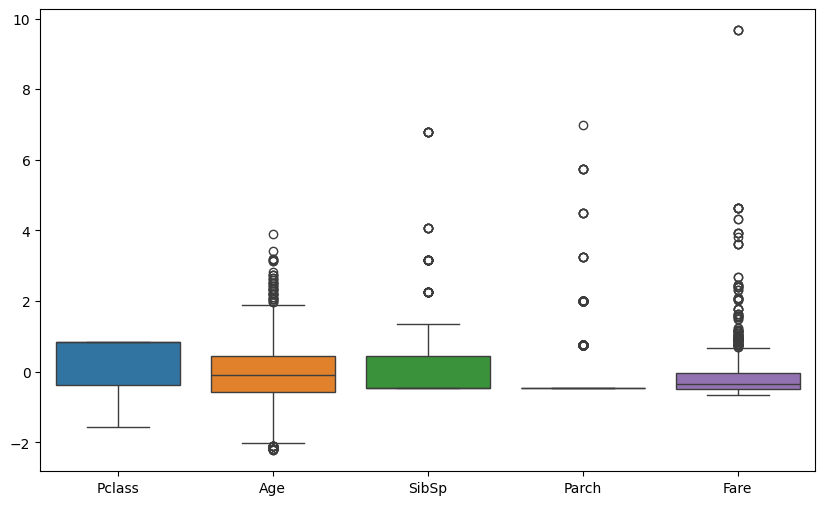

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[features])
plt.show()

## Remove Outliers

In [10]:
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]

## Final Dataset

In [11]:
df.reset_index(drop=True, inplace=True)

print(df.shape)
print(df.isnull().sum())
df.head()

(561, 9)
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
dtype: int64


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,0.827377,0,-0.565736,0.432793,-0.473674,-0.502445,False,True
1,1,0.827377,1,-0.258337,-0.474545,-0.473674,-0.488854,False,True
2,1,-1.566107,1,0.433312,0.432793,-0.473674,0.420730,False,True
3,0,0.827377,0,0.433312,-0.474545,-0.473674,-0.486337,False,True
4,0,0.827377,0,-0.104637,-0.474545,-0.473674,-0.478116,True,False


In [12]:
display(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,0.827377,0,-0.565736,0.432793,-0.473674,-0.502445,False,True
1,1,0.827377,1,-0.258337,-0.474545,-0.473674,-0.488854,False,True
2,1,-1.566107,1,0.433312,0.432793,-0.473674,0.420730,False,True
3,0,0.827377,0,0.433312,-0.474545,-0.473674,-0.486337,False,True
4,0,0.827377,0,-0.104637,-0.474545,-0.473674,-0.478116,True,False
...,...,...,...,...,...,...,...,...,...
556,0,0.827377,0,-0.335187,-0.474545,-0.473674,-0.506472,False,True
557,0,-0.369365,0,-0.181487,-0.474545,-0.473674,-0.386671,False,True
558,1,-1.566107,1,-0.796286,-0.474545,-0.473674,-0.044381,False,True
559,1,-1.566107,0,-0.258337,-0.474545,-0.473674,-0.044381,False,False


## Save Cleaned Dataset

In [13]:
df.to_csv('/kaggle/working/cleaned_titanic.csv', index=False)